**ASSIGNMENT 2 - Binary Classification using Naive Bayes and K-Nearest Neighbors**

NAME : MADUSSREE RAVI

CSE B

3122235001074

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("spambase_csv_Kaggle.csv")

In [3]:
num_colmn=df.select_dtypes(include=['int64','float64']).columns.tolist()
num_colmn

['word_freq_make',
 'word_freq_address',
 'word_freq_all',
 'word_freq_3d',
 'word_freq_our',
 'word_freq_over',
 'word_freq_remove',
 'word_freq_internet',
 'word_freq_order',
 'word_freq_mail',
 'word_freq_receive',
 'word_freq_will',
 'word_freq_people',
 'word_freq_report',
 'word_freq_addresses',
 'word_freq_free',
 'word_freq_business',
 'word_freq_email',
 'word_freq_you',
 'word_freq_credit',
 'word_freq_your',
 'word_freq_font',
 'word_freq_000',
 'word_freq_money',
 'word_freq_hp',
 'word_freq_hpl',
 'word_freq_george',
 'word_freq_650',
 'word_freq_lab',
 'word_freq_labs',
 'word_freq_telnet',
 'word_freq_857',
 'word_freq_data',
 'word_freq_415',
 'word_freq_85',
 'word_freq_technology',
 'word_freq_1999',
 'word_freq_parts',
 'word_freq_pm',
 'word_freq_direct',
 'word_freq_cs',
 'word_freq_meeting',
 'word_freq_original',
 'word_freq_project',
 'word_freq_re',
 'word_freq_edu',
 'word_freq_table',
 'word_freq_conference',
 'char_freq_%3B',
 'char_freq_%28',
 'char_freq_%5

In [4]:
df=df.drop_duplicates()
df

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


<Axes: xlabel='class', ylabel='count'>

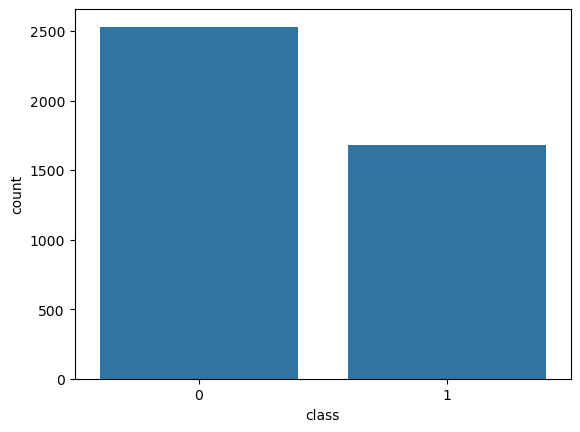

In [5]:
import seaborn as sns
sns.countplot(data=df,x="class")

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import math

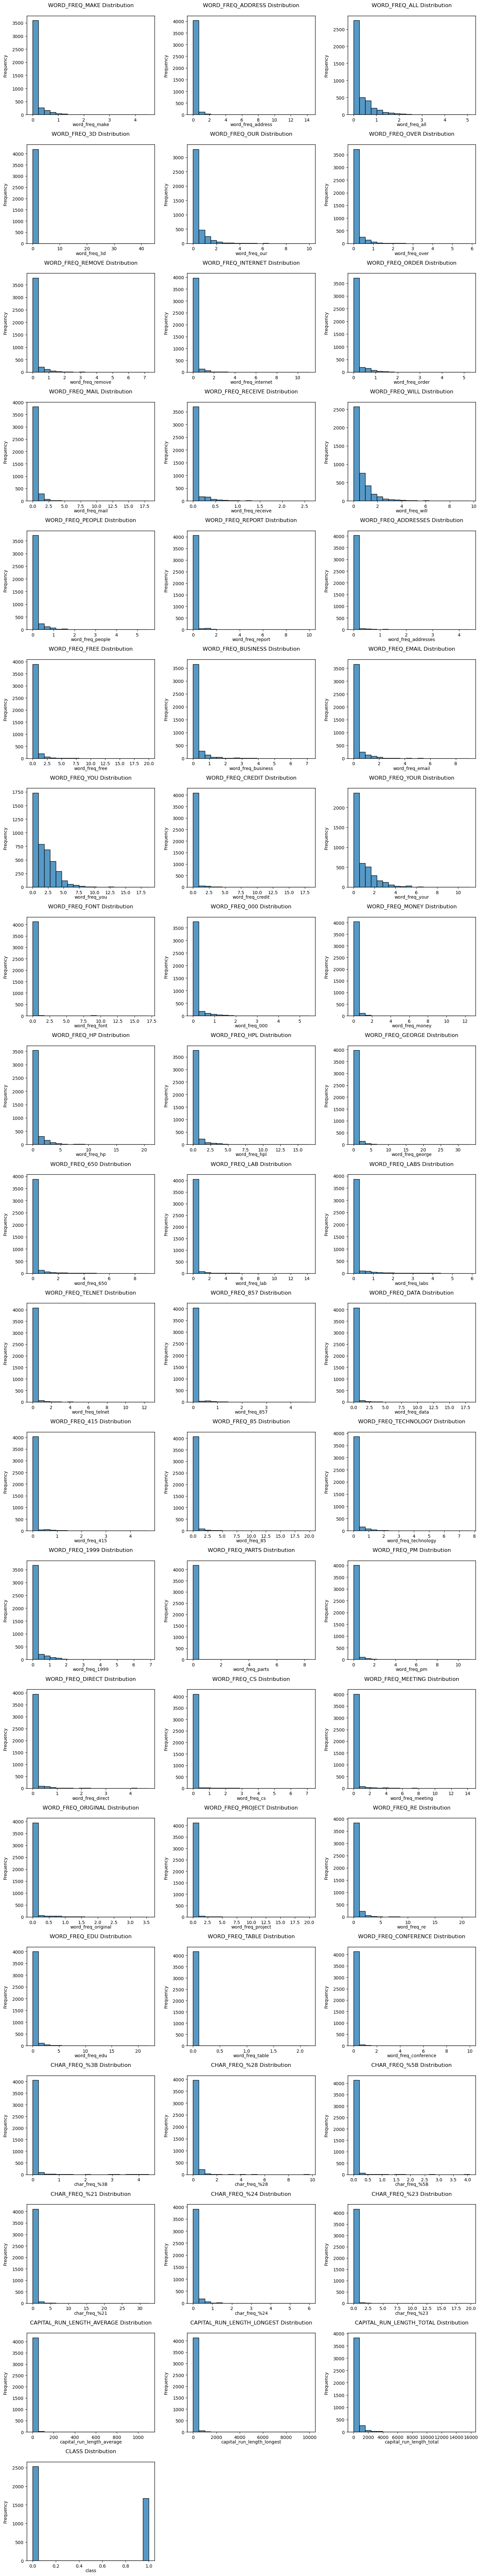

In [10]:
cols = df.columns
ncols = 3
nrows = math.ceil(len(cols) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

bxwidth = 1

for i, col in enumerate(cols):
    sns.histplot(df[col], bins=20, ax=axes[i])
    axes[i].set_title(f"{col.upper()} Distribution", pad=20)
    axes[i].set_xlabel(col, labelpad=0)
    axes[i].set_ylabel("Frequency", labelpad=10)
    for spine in axes[i].spines.values():
        spine.set_linewidth(bxwidth)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.subplots_adjust(hspace=1.5, wspace=1.3)
plt.tight_layout()
plt.show()


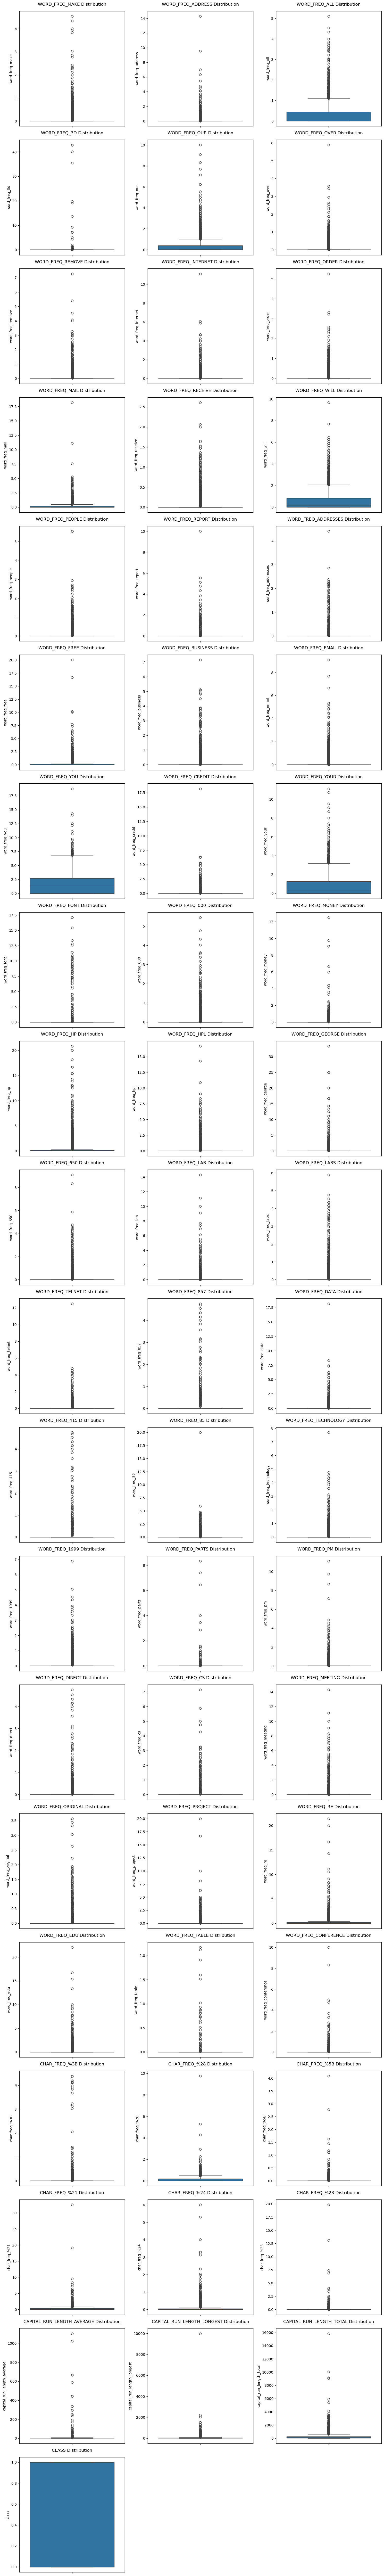

In [11]:
cols = df.columns
ncols = 3
nrows = math.ceil(len(cols) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

bxwidth = 1

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f"{col.upper()} Distribution", pad=15)
    axes[i].set_ylabel(col)
    for spine in axes[i].spines.values():
        spine.set_linewidth(bxwidth)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.subplots_adjust(hspace=1.2, wspace=0.8)
plt.tight_layout()
plt.show()

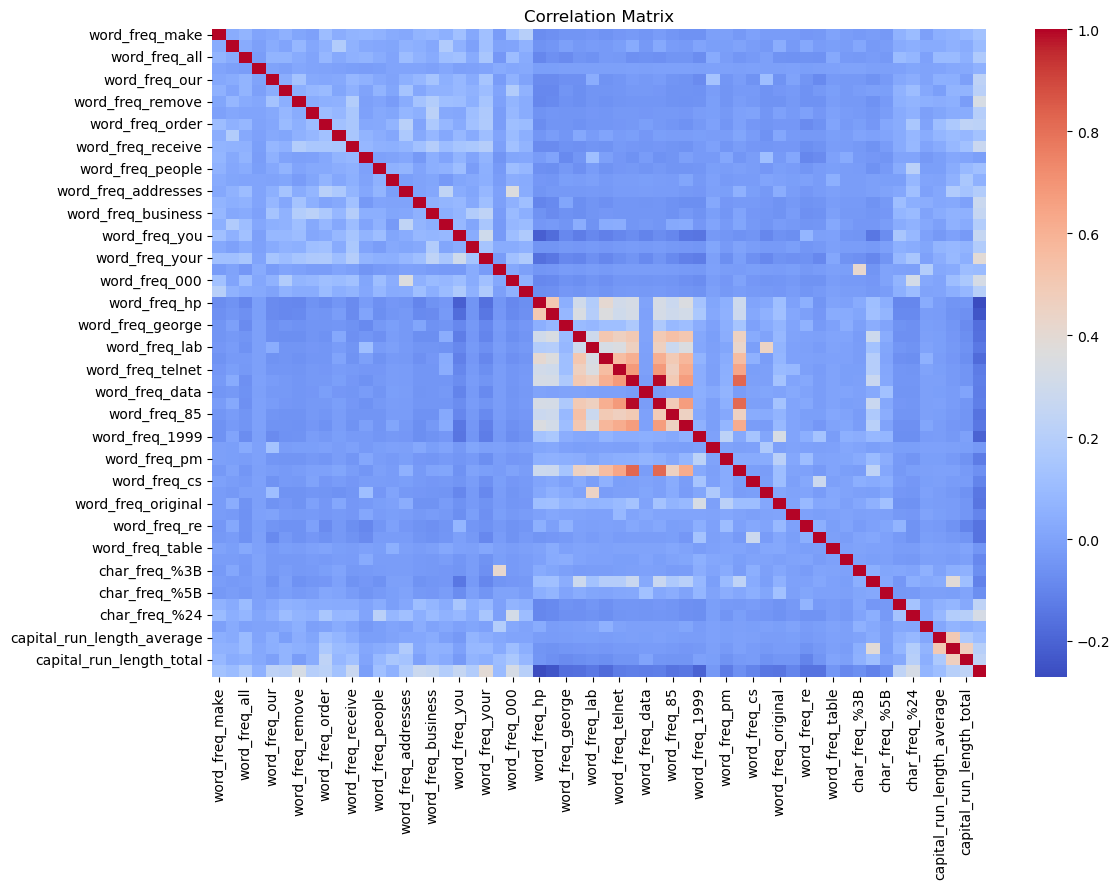

In [12]:
plt.figure(figsize=(12,9))
sns.heatmap(df[cols].corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


In [13]:
from sklearn.preprocessing import StandardScaler
import math
from matplotlib import rcParams
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

In [14]:
X=df.drop("class",axis=1)
print(X)
y=df["class"]
print(y)

      word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0               0.00               0.64           0.64           0.0   
1               0.21               0.28           0.50           0.0   
2               0.06               0.00           0.71           0.0   
3               0.00               0.00           0.00           0.0   
4               0.00               0.00           0.00           0.0   
...              ...                ...            ...           ...   
4596            0.31               0.00           0.62           0.0   
4597            0.00               0.00           0.00           0.0   
4598            0.30               0.00           0.30           0.0   
4599            0.96               0.00           0.00           0.0   
4600            0.00               0.00           0.65           0.0   

      word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0              0.32            0.00              0.00     

In [15]:
X=df.drop("class",axis=1)
X
y=df["class"]

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.25, random_state=42,stratify=y
)

In [17]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

**NAIVE BAYES**

In [18]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB
import time
start=time.time()
gnb=GaussianNB()
gnb.fit(X_train_scaled, y_train)
ttgnb=time.time()-start
start = time.time()
y_pred = gnb.predict(X_test_scaled)
pred_time_gnb = time.time() - start


In [19]:
print("The training time for Gaussian Naive Bayes is: ",ttgnb)

The training time for Gaussian Naive Bayes is:  0.014724969863891602


In [20]:
print("The prediction time for Gaussian Naive Bayes is: ",pred_time_gnb)

The prediction time for Gaussian Naive Bayes is:  0.003335714340209961


In [21]:
from sklearn.metrics import (
accuracy_score, precision_score, recall_score, f1_score,
confusion_matrix, classification_report, roc_auc_score,
roc_curve, average_precision_score)

In [26]:
print("Confusion matrix is \n",confusion_matrix(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
print("Specificity:", specificity)
false_positive_rate = fp / (fp + tn)
print("False Positive Rate:", false_positive_rate)

Confusion matrix is 
 [[473 160]
 [ 19 401]]
Specificity: 0.7472353870458136
False Positive Rate: 0.2527646129541864


In [27]:
print("Overall Report of model \n\n",classification_report(y_test,y_pred))

Overall Report of model 

               precision    recall  f1-score   support

           0       0.96      0.75      0.84       633
           1       0.71      0.95      0.82       420

    accuracy                           0.83      1053
   macro avg       0.84      0.85      0.83      1053
weighted avg       0.86      0.83      0.83      1053



In [28]:
start=time.time()
mnb=MultinomialNB()
mnb.fit(X_train,y_train)
ttmnb=time.time()-start
start=time.time()
y_pred=mnb.predict(X_test)
pred_time=time.time()-start

In [29]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix is \n",confusion_matrix(y_test,y_pred))
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
print("Specificity:", specificity)
false_positive_rate = fp / (fp + tn)
print("False Positive Rate:", false_positive_rate)

Confusion matrix is 
 [[552  81]
 [136 284]]
Specificity: 0.8720379146919431
False Positive Rate: 0.12796208530805686


In [30]:
print("Overall Report of model \n\n",classification_report(y_test,y_pred))

Overall Report of model 

               precision    recall  f1-score   support

           0       0.80      0.87      0.84       633
           1       0.78      0.68      0.72       420

    accuracy                           0.79      1053
   macro avg       0.79      0.77      0.78      1053
weighted avg       0.79      0.79      0.79      1053



In [31]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
start=time.time()
bnb=BernoulliNB()
bnb.fit(X_train,y_train)
ttbnb=time.time()-start
start=time.time()
y_pred = bnb.predict(X_test)
pred_time=time.time()-start

In [32]:
print("Confusion matrix is \n",confusion_matrix(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
print("Specificity:", specificity)
false_positive_rate = fp / (fp + tn)
print("False Positive Rate:", false_positive_rate)

Confusion matrix is 
 [[581  52]
 [ 66 354]]
Specificity: 0.9178515007898894
False Positive Rate: 0.08214849921011058


In [33]:
print("Overall Report of model \n\n",classification_report(y_test,y_pred))

Overall Report of model 

               precision    recall  f1-score   support

           0       0.90      0.92      0.91       633
           1       0.87      0.84      0.86       420

    accuracy                           0.89      1053
   macro avg       0.88      0.88      0.88      1053
weighted avg       0.89      0.89      0.89      1053



**KNN**

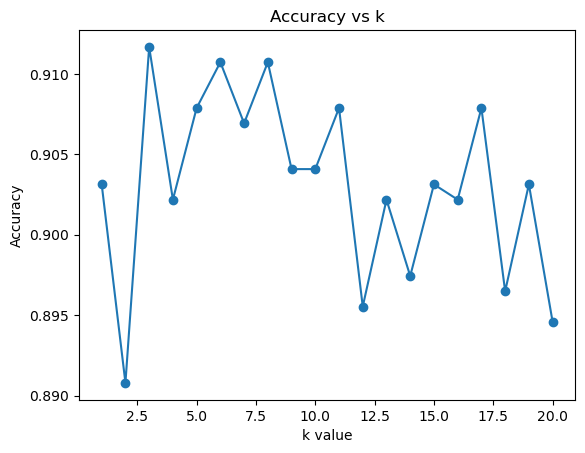

In [34]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled,y_train)
y_pred_knn=knn.predict(X_test_scaled)
k_values = range(1, 21)
accuracies = []
for k in k_values:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train_scaled, y_train)
  accuracies.append(knn.score(X_test_scaled, y_test))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.title('Accuracy vs k')
plt.show()

In [36]:
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scores_base=cross_val_score(
    knn,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring='accuracy'
)
print("Base KNN CV Accuracy:",cv_scores_base.mean())

Base KNN CV Accuracy: 0.8777252301951896


In [37]:
param_grid = {
    'n_neighbors': list(range(1, 31, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(
    knn,
    param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

best_k = grid.best_params_['n_neighbors']

print("Grid Best Params:", grid.best_params_)
print("Best k (n_neighbors):", best_k)
print("Grid Best CV Accuracy:", grid.best_score_)

Grid Best Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best k (n_neighbors): 9
Grid Best CV Accuracy: 0.9151136432024713


In [38]:
from scipy.stats import randint
param_dist={
    'n_neighbors':randint(1,30),
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan']
}
rand=RandomizedSearchCV(
    knn,
    param_distributions=param_dist,
    n_iter=15,
    cv=skf,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
rand.fit(X_train_scaled,y_train)
best_k = rand.best_params_['n_neighbors']
print("Random Best Params:",rand.best_params_)
print("Best k (n_neighbors):", best_k)
print("Random Best CV Accuracy:",rand.best_score_)

Random Best Params: {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}
Best k (n_neighbors): 6
Random Best CV Accuracy: 0.9106782483098959


In [39]:
best_params=rand.best_params_
knn_final=KNeighborsClassifier(
    n_neighbors=best_params['n_neighbors'],
    weights=best_params['weights'],
    metric=best_params['metric']
)
knn_final.fit(X_train_scaled,y_train)
y_pred_final=knn_final.predict(X_test_scaled)

In [40]:
from sklearn.metrics import confusion_matrix,roc_curve,auc
def compute_metrics(y_true,y_pred):
    cm=confusion_matrix(y_true,y_pred)
    tn,fp,fn,tp=cm.ravel()
    accuracy=(tp+tn)/(tp+tn+fp+fn)
    precision=tp/(tp+fp)
    recall=tp/(tp+fn)
    f1=2*precision*recall/(precision+recall)
    specificity=tn/(tn+fp)
    fpr=fp/(fp+tn)
    return accuracy,precision,recall,f1,specificity,fpr,cm

In [42]:
start=time.time()
knn_final.fit(X_train_scaled,y_train)
train_time=time.time()-start

start=time.time()
y_pred_knn=knn_final.predict(X_test_scaled)
pred_time=time.time()-start
acc,prec,rec,f1,spec,fpr,cm=compute_metrics(y_test,y_pred_knn)
print("Final KNN Metrics")
print("Accuracy:",acc)
print("Precision:",prec)
print("Recall:",rec)
print("F1 Score:",f1)
print("Specificity:",spec)
print("False Positive Rate:",fpr)
print("Training Time:",train_time)
print("Prediction Time:",pred_time)

Final KNN Metrics
Accuracy: 0.9230769230769231
Precision: 0.937984496124031
Recall: 0.8642857142857143
F1 Score: 0.8996282527881042
Specificity: 0.9620853080568721
False Positive Rate: 0.037914691943127965
Training Time: 0.0026731491088867188
Prediction Time: 0.05989694595336914


In [43]:
best_params=rand.best_params_
optimal_k=best_params['n_neighbors']
optimal_k

6

**KD TREE**

In [44]:
start=time.time()
knn_kd=KNeighborsClassifier(
    n_neighbors=optimal_k,
    weights=best_params['weights'],
    metric=best_params['metric'],
    algorithm='kd_tree'
)
knn_kd.fit(X_train_scaled,y_train)
train_time_kd=time.time()-start
start=time.time()
y_pred_kd=knn_kd.predict(X_test_scaled)
pred_time_kd=time.time()-start

In [46]:
acc_kd,prec_kd,rec_kd,f1_kd,sp,fpr,cm=compute_metrics(y_test,y_pred_kd)
print("Final KDtree Metrics")
print("Accuracy:",acc_kd)
print("Precision:",prec_kd)
print("Recall:",rec_kd)
print("F1 Score:",f1_kd)
print("Specificity:",sp)
print("False Positive Rate:",fpr)
print("Training Time:",train_time)
print("Prediction Time:",pred_time)

Final KDtree Metrics
Accuracy: 0.9230769230769231
Precision: 0.937984496124031
Recall: 0.8642857142857143
F1 Score: 0.8996282527881042
Specificity: 0.9620853080568721
False Positive Rate: 0.037914691943127965
Training Time: 0.0026731491088867188
Prediction Time: 0.05989694595336914


**KD BALL TREE**

In [47]:
start=time.time()
knn_bt=KNeighborsClassifier(
    n_neighbors=optimal_k,
    weights=best_params['weights'],
    metric=best_params['metric'],
    algorithm='ball_tree'
)
knn_bt.fit(X_train_scaled,y_train)
train_time_bt=time.time()-start
start=time.time()
y_pred_bt=knn_bt.predict(X_test_scaled)
pred_time_bt=time.time()-start

In [48]:
acc_bt,prec_bt,rec_bt,f1_bt,sp,fpr,cm=compute_metrics(y_test,y_pred_bt)
print("Final Balltree Metrics")
print("Accuracy:",acc_bt)
print("Precision:",prec_bt)
print("Recall:",rec_bt)
print("F1 Score:",f1_bt)
print("Specificity:",sp)
print("False Positive Rate:",fpr)
print("Training Time:",train_time)
print("Prediction Time:",pred_time)

Final Balltree Metrics
Accuracy: 0.9230769230769231
Precision: 0.937984496124031
Recall: 0.8642857142857143
F1 Score: 0.8996282527881042
Specificity: 0.9620853080568721
False Positive Rate: 0.037914691943127965
Training Time: 0.0026731491088867188
Prediction Time: 0.05989694595336914


In [49]:
gnb_scores=cross_val_score(
    GaussianNB(),
    X_train,
    y_train,
    cv=skf,
    scoring='accuracy'
)

In [50]:
mnb_scores=cross_val_score(
    MultinomialNB(),
    X_train,
    y_train,
    cv=skf,
    scoring='accuracy'
)

In [51]:
bnb_scores=cross_val_score(
    BernoulliNB(),
    X_train,
    y_train,
    cv=skf,
    scoring='accuracy'
)

In [52]:
knn_kd_scores=cross_val_score(
    knn_kd,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring='accuracy'
)

In [53]:
knn_bt_scores=cross_val_score(
    knn_bt,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring='accuracy'
)

In [54]:
print("Gaussian NB Mean Accuracy:",gnb_scores.mean())
print("Multinomial NB Mean Accuracy:",mnb_scores.mean())
print("Bernoulli NB Mean Accuracy:",bnb_scores.mean())
print("KNN KDTree Mean Accuracy:",knn_kd_scores.mean())
print("KNN BallTree Mean Accuracy:",knn_bt_scores.mean())

Gaussian NB Mean Accuracy: 0.8270486870348452
Multinomial NB Mean Accuracy: 0.7934637605568818
Bernoulli NB Mean Accuracy: 0.888503781419888
KNN KDTree Mean Accuracy: 0.9106782483098959
KNN BallTree Mean Accuracy: 0.9106782483098959


In [55]:
best_model=max(
    [
        ("Gaussian NB",gnb_scores.mean()),
        ("Multinomial NB",mnb_scores.mean()),
        ("Bernoulli NB",bnb_scores.mean()),
        ("KNN KDTree",knn_kd_scores.mean()),
        ("KNN BallTree",knn_bt_scores.mean())
    ],
    key=lambda x:x[1]
)

print("Best Model:",best_model)

Best Model: ('KNN KDTree', np.float64(0.9106782483098959))
